---
title: Pronóstico de Series Temporales con RNNs en PyTorch
subject: Aprendizaje Profundo
subtitle: 
short_title: Pronóstico series temporales
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorgeanais/libro_aprendizaje_profundo/blob/main/cap3/020_RNN_PyTorch.ipynb)


**Objetivo**: Preparar datos de series temporales para entrenar modelos de aprendizaje profundo e implementar una RNN simple desde cero y con el módulo `nn.RNN` de PyTorch para pronosticar demanda de pasajeros de metro.


## <font color="purple">Preparativos</font>

Instalamos y verificamos las librerías necesarias.


In [ ]:
import sys
import time
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo : {device}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")


Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch : 2.10.0+cpu
Dispositivo : cpu


---
## <font color="purple">1. El Dataset: Afluencia en el Metro de Chicago</font>

Trabajaremos con datos históricos de afluencia diaria en el sistema de metro (rail) de Chicago. El objetivo es **predecir la afluencia del día de mañana** usando los últimos 56 días como ventana de contexto.

El dataset contiene registros desde 2001. Usaremos:
- **Entrenamiento**: Enero 2016 – Diciembre 2018
- **Validación**: Enero 2019 – Mayo 2019
- **Prueba**: Junio 2019 en adelante

La columna `day_type` indica el tipo de día:
- **W** → Día de semana (*Weekday*)
- **A** → Sábado
- **U** → Domingo o feriado


In [ ]:
url = "https://raw.githubusercontent.com/jorgeanais/mlt2202/refs/heads/main/ea3/s7/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(url, index_col="service_date", parse_dates=True)
df.sort_index(inplace=True)
print(df.shape)
df.head()


(7701, 4)


,day_type,bus,rail_boardings,total_rides
service_date,,,,
2001-01-01,U,297192,126455,423647
2001-01-02,W,780827,501952,1282779
2001-01-03,W,824923,536432,1361355
2001-01-04,W,870021,550011,1420032
2001-01-05,W,890426,557917,1448343


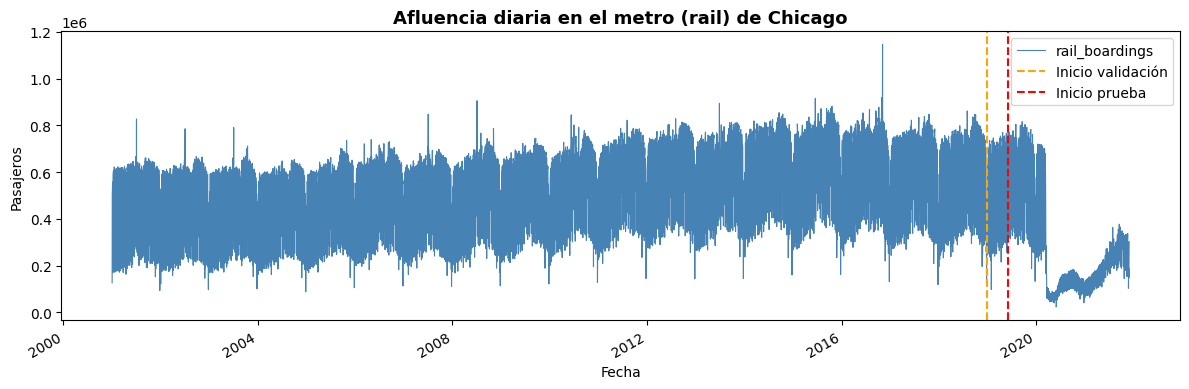

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
df["rail_boardings"].plot(ax=ax, color="steelblue", linewidth=0.8)
ax.set_title("Afluencia diaria en el metro (rail) de Chicago", fontsize=13, fontweight="bold")
ax.set_ylabel("Pasajeros")
ax.set_xlabel("Fecha")
ax.axvline(pd.Timestamp("2019-01-01"), color="orange", linestyle="--", label="Inicio validación")
ax.axvline(pd.Timestamp("2019-06-01"), color="red",    linestyle="--", label="Inicio prueba")
ax.legend()
plt.tight_layout()
plt.show()


> 📌 **Concepto clave — División temporal**
>
> A diferencia de los datasets de imágenes, en series temporales **nunca debemos mezclar el futuro con el pasado** al dividir los datos. Siempre dividimos respetando el eje del tiempo: entrenamos con lo más antiguo y evaluamos con lo más reciente.


---
### <font color="blue">**Actividad 1.** Exploración del dataset</font>

<font color="green">Antes de modelar, es fundamental entender los datos. Responde las siguientes preguntas observando la gráfica y explorando el DataFrame:</font>

<font color="green">1. ¿Qué patrón estacional observas en los datos?</font>   
<font color="green">2. Calcula la media y la desviación estándar de la columna `rail_boardings` para cada año. ¿Hay tendencia creciente o decreciente?</font>   
<font color="green">3. ¿Por qué dividimos el período de validación en los primeros 5 meses de 2019 en lugar de un año completo?</font>


Media y desviación estándar anual de afluencia ferroviaria:
                       mean            std
service_date                              
2001          497788.734247  171132.946678
2002          494245.558904  165064.874387
2003          496260.536986  161960.138507
2004          488296.360656  156054.216776
2005          511669.931507  157968.402543
2006          534710.446575  162449.379277
2007          521297.024658  161595.562671
2008          541358.614754  168064.692348
2009          554983.671233  158682.573094
2010          577668.695890  160633.108852
2011          610773.002525  163521.219011
2012          631569.232240  167711.393927
2013          626532.600000  166508.899641
2014          653748.457071  170521.125920
2015          662126.205479  180046.506252
2016          652037.737705  180024.552290
2017          630696.019178  180681.606811
2018          618890.282192  184729.755113
2019          598540.112329  186563.167389
2020          207786.532787  197675.1

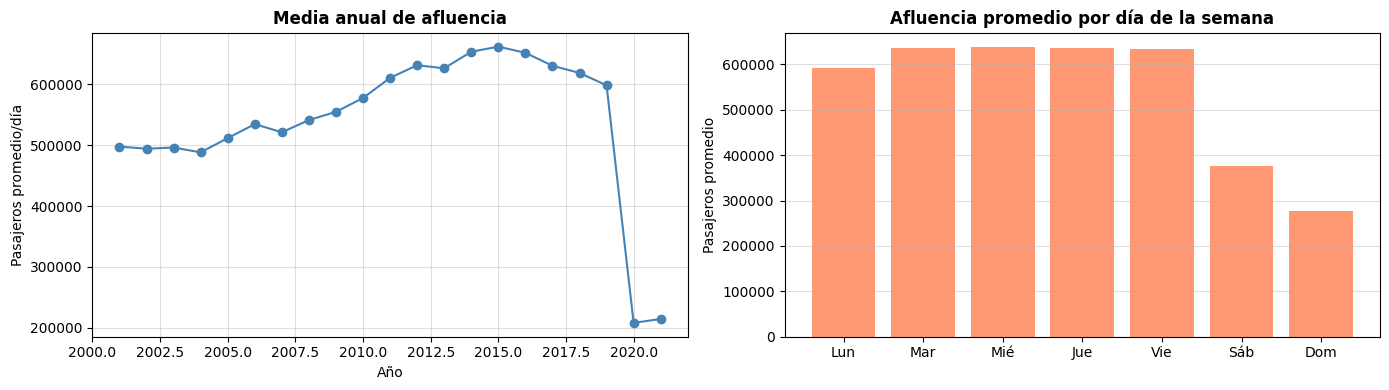

Variación 2016→2018 en media diaria: -33,147 pasajeros


In [ ]:
# ── Estadísticas anuales ──────────────────────────────────────────────────────
stats_yearly = df["rail_boardings"].resample("YE").agg(["mean", "std"])
stats_yearly.index = stats_yearly.index.year
print("Media y desviación estándar anual de afluencia ferroviaria:")
print(stats_yearly.to_string())
print()

# ── Visualización de tendencia ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1: Media anual
stats_yearly["mean"].plot(ax=axes[0], marker="o", color="steelblue")
axes[0].set_title("Media anual de afluencia", fontweight="bold")
axes[0].set_ylabel("Pasajeros promedio/día")
axes[0].set_xlabel("Año")
axes[0].grid(alpha=0.4)

# Gráfico 2: Descomposición estacional — promedio por día de la semana
dow_avg = df["rail_boardings"].groupby(df.index.dayofweek).mean()
dow_labels = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
axes[1].bar(dow_labels, dow_avg.values, color="coral", alpha=0.8)
axes[1].set_title("Afluencia promedio por día de la semana", fontweight="bold")
axes[1].set_ylabel("Pasajeros promedio")
axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

# Tendencia: diferencia entre 2018 y 2016
delta = stats_yearly.loc[2018, "mean"] - stats_yearly.loc[2016, "mean"]
print(f"Variación 2016→2018 en media diaria: {delta:+,.0f} pasajeros")


<details>
<summary>👉 Clic para ver respuesta orientativa</summary>

**1. Patrón estacional**: La serie muestra una clara estacionalidad semanal (fines de semana vs días hábiles). Esto es esperado en sistemas de transporte masivo.

**2. Tendencia**: El gráfico de media anual muestra un crecimiento constante desde el año 2001 a 2015, luego una ligero decrecimiento hasta 2019. El 2020 la cantidad de pasajeros baja drásticamente.

**3. Período de validación corto**: Se usan solo 5 meses para dejar suficientes datos de test. En producción, lo ideal es tener al menos un ciclo estacional completo en validación, pero depende del volumen disponible.
</details>


## <font color="purple">2. Preparación de los Datos: `TimeSeriesDataset`</font>

Los modelos ML clásicos esperan pares `(X, y)` independientes. Para series temporales debemos crear esos pares manualmente: cada muestra es una **ventana deslizante** de `window_length` pasos, y el target es el valor inmediatamente siguiente.

```
Serie: [0, 1, 2, 3, 4, 5]  →  ventana=3

X:  [0, 1, 2]  →  y: 3
X:  [1, 2, 3]  →  y: 4
X:  [2, 3, 4]  →  y: 5
```

Las RNNs esperan tensores 2D por secuencia: `[longitud_ventana, dimensionalidad]`. Para series univariadas, la dimensionalidad es **1**.


In [ ]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end    = idx + self.window_length
        window = self.series[idx : end]
        target = self.series[end]
        return window, target


### <font color="purple">2.1 Prueba con una serie simple</font>

Antes de aplicar la clase al dataset real, la validamos con una serie pequeña y predecible:


In [ ]:
my_series  = torch.tensor([[0], [1], [2], [3], [4], [5]])
my_dataset = TimeSeriesDataset(my_series, window_length=3)

print(f"Número de muestras en el dataset: {len(my_dataset)}\n")
for window, target in my_dataset:
    print(f"Ventana: {window.flatten().tolist()}  →  Target: {target.item()}")


Número de muestras en el dataset: 3

Ventana: [0, 1, 2]  →  Target: 3
Ventana: [1, 2, 3]  →  Target: 4
Ventana: [2, 3, 4]  →  Target: 5


In [ ]:
torch.manual_seed(0)
my_loader = DataLoader(my_dataset, batch_size=2, shuffle=True)

print("Batches generados por el DataLoader:")
for i, (X, y) in enumerate(my_loader):
    print(f"  Batch {i+1}: X.shape={X.shape}, y.shape={y.shape}")
    print(f"    X = {X.squeeze(-1).tolist()}")
    print(f"    y = {y.squeeze(-1).tolist()}")


Batches generados por el DataLoader:
  Batch 1: X.shape=torch.Size([2, 3, 1]), y.shape=torch.Size([2, 1])
    X = [[0, 1, 2], [2, 3, 4]]
    y = [3, 5]
  Batch 2: X.shape=torch.Size([1, 3, 1]), y.shape=torch.Size([1, 1])
    X = [[1, 2, 3]]
    y = [4]


> 📌 **¿Por qué `shuffle=True` en entrenamiento?**
>
> El descenso de gradiente asume que las muestras son IID (independientes e idénticamente distribuidas). Al mezclar las ventanas rompemos la correlación temporal **entre ventanas contiguas**, aunque el orden interno de cada ventana se preserva. Sin esto, la red aprendería artefactos del orden de presentación.


---
### <font color="blue">**Actividad 2.** Análisis de la clase `TimeSeriesDataset`</font>

<font color="green">
Responde las siguientes preguntas razonando sobre el código:

1. Si la serie tiene 1000 puntos y `window_length=56`, ¿cuántas muestras tendrá el dataset?
2. ¿Por qué el dataset tiene forma `[window_length, 1]` y no `[window_length]`? ¿Qué módulo de PyTorch lo requiere así?
3. Si tuvieras una serie **multivariada** con 3 variables (por ejemplo, rail, bus y taxi), ¿qué cambiarías en la clase? ¿Y en el modelo?
</font>


In [ ]:
n_puntos  = 1000
ventana   = 56
n_muestras = n_puntos - ventana
print(f"Número de muestras: {n_muestras}")


Número de muestras: 944


<details>
<summary>👉 Clic para ver respuesta orientativa</summary>

**1.** `len = 1000 - 56 = 944` muestras.

**2.** El módulo `nn.RNN` espera entradas de forma `[batch, seq_len, dimensionality]`. Para una serie univariada, `dimensionality=1`, de ahí que cada punto se representa como `[valor]` y no como un escalar.

**3.** Para series multivariadas, simplemente se usa `df[["rail", "bus", "taxi"]]` al crear el tensor (`dimensionality=3`). El modelo debe actualizar `input_size=3`. El target puede seguir siendo univariado si solo se quiere predecir `rail`.
</details>


---
## <font color="purple">3. Preparación del Dataset Real</font>

Dividimos la serie de afluencia ferroviaria en tres conjuntos y creamos los DataLoaders correspondientes. Escalamos los valores dividiéndolos por 1 millón para que queden cerca del rango [0, 1], lo que favorece la inicialización por defecto de pesos y la tasa de aprendizaje.


In [ ]:
rail_train = torch.FloatTensor(df[["rail_boardings"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail_boardings"]]["2019-01":"2019-05"].values / 1e6)
rail_test  = torch.FloatTensor(df[["rail_boardings"]]["2019-06":].values  / 1e6)

print(f"Entrenamiento : {rail_train.shape}")
print(f"Validación    : {rail_valid.shape}")
print(f"Prueba        : {rail_test.shape}")


Entrenamiento : torch.Size([1096, 1])
Validación    : torch.Size([151, 1])
Prueba        : torch.Size([914, 1])


In [ ]:
window_length = 56  # 8 semanas de contexto

train_set = TimeSeriesDataset(rail_train, window_length)
valid_set = TimeSeriesDataset(rail_valid, window_length)
test_set  = TimeSeriesDataset(rail_test,  window_length)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader  = DataLoader(test_set,  batch_size=32)

X_sample, y_sample = next(iter(train_loader))
print(f"Batch de entrenamiento: X={X_sample.shape}, y={y_sample.shape}")


Batch de entrenamiento: X=torch.Size([32, 56, 1]), y=torch.Size([32, 1])



## <font color="purple">4. RNN Simple Desde Cero</font>

Antes de usar el módulo integrado de PyTorch, construiremos la RNN a mano para entender cada pieza. En cada tiempo $t$, la célula de memoria recibe la entrada actual $\mathbf{x}^{(t)}$ y el estado oculto anterior $\mathbf{h}^{(t-1)}$, y produce el nuevo estado oculto $\mathbf{h}^{(t)}$:

$$\mathbf{h}^{(t)} = \tanh\left(\mathbf{W}_{xh} \mathbf{x}^{(t)} + \mathbf{W}_{hh} \mathbf{h}^{(t-1)} + \mathbf{b}\right)$$

Al final de la secuencia, el último estado oculto $\mathbf{h}^{(N)}$ pasa por una capa lineal para obtener el pronóstico.

![figura](https://github.com/jorgeanais/mlt2202/blob/main/ea3/s7/fignote2.png?raw=true)

In [ ]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.Sequential(
            nn.Linear(input_size + hidden_size, hidden_size),
            nn.Tanh()
        )
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            XH = torch.cat((X_t, H), dim=1)
            H  = self.memory_cell(XH)
        return self.output(H)


torch.manual_seed(42)
univar_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)
print(univar_model)
total_params = sum(p.numel() for p in univar_model.parameters())
print(f"\nParámetros totales: {total_params:,}")


SimpleRnnModel(
  (memory_cell): Sequential(
    (0): Linear(in_features=33, out_features=32, bias=True)
    (1): Tanh()
  )
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Parámetros totales: 1,121


---
### <font color="blue">**Actividad 3.** Dimensiones en la RNN manual</font>

<font color="green">
Completa la siguiente tabla calculando las dimensiones de los tensores en cada paso del método `forward()` para un batch de 32 muestras con ventana de 56 y `hidden_size=32`:
</font>

| Tensor | Descripción | Forma (tu respuesta) |
|--------|-------------|---------------------|
| `X` (entrada) | Batch de ventanas | `[32, 56, 1]` ✓ |
| `X_time_first` | Tras transpose | ❓ |
| `H` (inicial) | Estado oculto inicial | ❓ |
| `X_t` | Un paso de tiempo | ❓ |
| `XH` | Concatenación de X_t y H | ❓ |
| `H` (tras memoria) | Nuevo estado oculto | ❓ |
| Salida `output(H)` | Pronóstico final | ❓ |

<details>
<summary>👉 Clic para ver respuesta</summary>

| Tensor | Forma |
|--------|-------|
| `X_time_first` | `[56, 32, 1]` |
| `H` inicial | `[32, 32]` |
| `X_t` | `[32, 1]` |
| `XH` | `[32, 33]` (1+32) |
| `H` tras memoria | `[32, 32]` |
| Salida | `[32, 1]` |

</details>


## Métricas de evaluación: MAE y MAPE

Para cuantificar la calidad del pronóstico, usaremos dos métricas:

- **MAE** (*Mean Absolute Error*): promedio del valor absoluto de los errores.
$$\text{MAE} = \frac{1}{n}\sum_{t}|x_t - \hat{x}_t|$$

- **MAPE** (*Mean Absolute Percentage Error*): MAE expresado como porcentaje del valor real.
$$\text{MAPE} = \frac{1}{n}\sum_{t}\left|\frac{x_t - \hat{x}_t}{x_t}\right|$$



## <font color="purple">5. Entrenamiento y Evaluación</font>

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device, max_norm=1.0):
    """Entrena un epoch. Incluye gradient clipping para estabilidad."""
    model.train()
    total_loss = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(X)
        loss   = criterion(y_pred, y)
        loss.backward()
        # gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
        optimizer.step()
        total_loss += loss.item() * len(X)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss   = criterion(y_pred, y)
            total_loss += loss.item() * len(X)
    return total_loss / len(loader.dataset)


def train_model(model, train_loader, valid_loader,
                n_epochs=40, lr=1e-3, patience=8):
    """
    Entrena el modelo con:
      - Adam + gradient clipping
      - Early stopping basado en valid_mae
      - Guarda el mejor modelo según validación (best-model checkpointing)
    """
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    history = {"train_mae": [], "valid_mae": []}
    best_valid_mae  = float("inf")
    best_state_dict = None
    epochs_no_improve = 0

    for epoch in range(1, n_epochs + 1):
        train_mae = train_epoch(model, train_loader, optimizer, criterion, device)
        valid_mae = evaluate(model, valid_loader, criterion, device)

        history["train_mae"].append(train_mae)
        history["valid_mae"].append(valid_mae)

        # best-model checkpointing
        if valid_mae < best_valid_mae:
            best_valid_mae  = valid_mae
            best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            marker = " ✓"
        else:
            epochs_no_improve += 1
            marker = ""

        print(f"Época {epoch:3d}/{n_epochs} | "
              f"Train MAE: {train_mae * 1e6:,.0f} | "
              f"Valid MAE: {valid_mae * 1e6:,.0f}{marker}")

        # early stopping
        if epochs_no_improve >= patience:
            print(f"\n⏹ Early stopping en época {epoch} "
                  f"(sin mejora por {patience} épocas).")
            break

    # Restaurar mejor estado
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        print(f"\n✅ Mejor Valid MAE: {best_valid_mae * 1e6:,.0f} pasajeros "
              f"→ pesos restaurados.")

    return history

In [ ]:
torch.manual_seed(42)
simple_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)

print("=== Entrenando RNN manual ===")
history_simple = train_model(simple_model, train_loader, valid_loader, n_epochs=40, patience=8)


=== Entrenando RNN manual ===
Época   1/40 | Train MAE: 370,419 | Valid MAE: 193,142 ✓
Época   2/40 | Train MAE: 143,429 | Valid MAE: 140,808 ✓
Época   3/40 | Train MAE: 134,326 | Valid MAE: 140,446 ✓
Época   4/40 | Train MAE: 132,207 | Valid MAE: 121,208 ✓
Época   5/40 | Train MAE: 130,049 | Valid MAE: 121,868
Época   6/40 | Train MAE: 127,880 | Valid MAE: 121,657
Época   7/40 | Train MAE: 124,279 | Valid MAE: 118,393 ✓
Época   8/40 | Train MAE: 103,596 | Valid MAE: 85,117 ✓
Época   9/40 | Train MAE: 73,727 | Valid MAE: 64,683 ✓
Época  10/40 | Train MAE: 68,119 | Valid MAE: 61,308 ✓
Época  11/40 | Train MAE: 67,727 | Valid MAE: 67,364
Época  12/40 | Train MAE: 65,235 | Valid MAE: 55,464 ✓
Época  13/40 | Train MAE: 62,618 | Valid MAE: 73,134
Época  14/40 | Train MAE: 62,677 | Valid MAE: 59,533
Época  15/40 | Train MAE: 61,172 | Valid MAE: 62,286
Época  16/40 | Train MAE: 60,313 | Valid MAE: 60,330
Época  17/40 | Train MAE: 59,554 | Valid MAE: 55,597
Época  18/40 | Train MAE: 52,635 | V

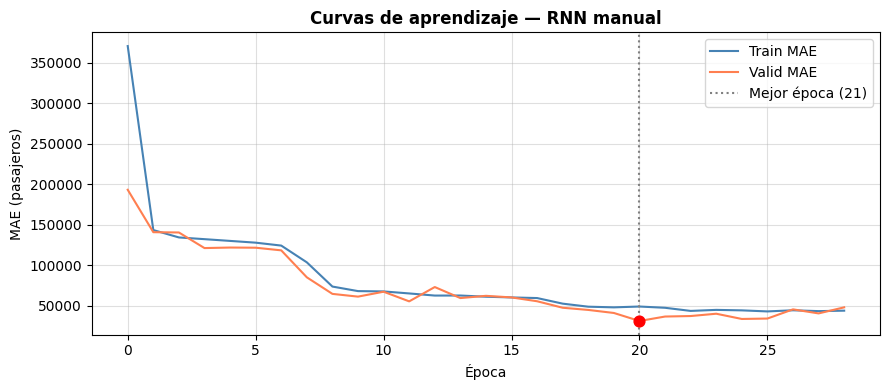

Mejor Valid MAE: 31,266 pasajeros (época 21)


In [ ]:
def plot_learning_curves(history, title="Curvas de aprendizaje"):
    """Visualiza train/valid MAE con anotación del mejor epoch."""
    train_vals = [v * 1e6 for v in history["train_mae"]]
    valid_vals = [v * 1e6 for v in history["valid_mae"]]
    best_epoch = int(np.argmin(valid_vals)) + 1

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(train_vals, label="Train MAE",  color="steelblue")
    ax.plot(valid_vals, label="Valid MAE",  color="coral")
    ax.axvline(best_epoch - 1, color="grey", linestyle=":", linewidth=1.5,
               label=f"Mejor época ({best_epoch})")
    ax.scatter(best_epoch - 1, valid_vals[best_epoch - 1],
               color="red", zorder=5, s=60)
    ax.set_xlabel("Época")
    ax.set_ylabel("MAE (pasajeros)")
    ax.set_title(title, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(f"Mejor Valid MAE: {min(valid_vals):,.0f} pasajeros (época {best_epoch})")

plot_learning_curves(history_simple, "Curvas de aprendizaje — RNN manual")

---
## <font color="purple">6. RNN con el Módulo `nn.RNN` de PyTorch</font>

PyTorch ofrece el módulo `nn.RNN` que encapsula toda la lógica anterior de forma optimizada. Cuando se usa una GPU NVIDIA, internamente aprovecha la biblioteca **cuDNN** para acelerar los cálculos.

Observa cuánto más compacto queda el código:


In [ ]:
class RnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.rnn    = nn.RNN(input_size, hidden_size,
                             num_layers=num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)          # outputs: [batch, seq, hidden]
        return self.output(outputs[:, -1])  # último paso de tiempo


torch.manual_seed(42)
rnn_model = RnnModel(input_size=1, hidden_size=32, output_size=1)
print(rnn_model)
total_params = sum(p.numel() for p in rnn_model.parameters())
print(f"\nParámetros totales: {total_params:,}")


RnnModel(
  (rnn): RNN(1, 32, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Parámetros totales: 1,153


In [ ]:
print("=== Entrenando nn.RNN (PyTorch) ===")
history_rnn = train_model(rnn_model, train_loader, valid_loader, n_epochs=40, patience=8)


=== Entrenando nn.RNN (PyTorch) ===
Época   1/40 | Train MAE: 258,525 | Valid MAE: 128,630 ✓
Época   2/40 | Train MAE: 138,859 | Valid MAE: 135,170
Época   3/40 | Train MAE: 134,730 | Valid MAE: 138,955
Época   4/40 | Train MAE: 133,339 | Valid MAE: 137,105
Época   5/40 | Train MAE: 124,864 | Valid MAE: 108,768 ✓
Época   6/40 | Train MAE: 105,086 | Valid MAE: 94,558 ✓
Época   7/40 | Train MAE: 100,018 | Valid MAE: 102,930
Época   8/40 | Train MAE: 95,636 | Valid MAE: 89,549 ✓
Época   9/40 | Train MAE: 92,760 | Valid MAE: 90,409
Época  10/40 | Train MAE: 85,621 | Valid MAE: 79,913 ✓
Época  11/40 | Train MAE: 70,376 | Valid MAE: 62,027 ✓
Época  12/40 | Train MAE: 65,564 | Valid MAE: 61,684 ✓
Época  13/40 | Train MAE: 63,387 | Valid MAE: 61,950
Época  14/40 | Train MAE: 63,589 | Valid MAE: 54,495 ✓
Época  15/40 | Train MAE: 62,261 | Valid MAE: 56,532
Época  16/40 | Train MAE: 61,621 | Valid MAE: 57,318
Época  17/40 | Train MAE: 59,695 | Valid MAE: 53,060 ✓
Época  18/40 | Train MAE: 57,755

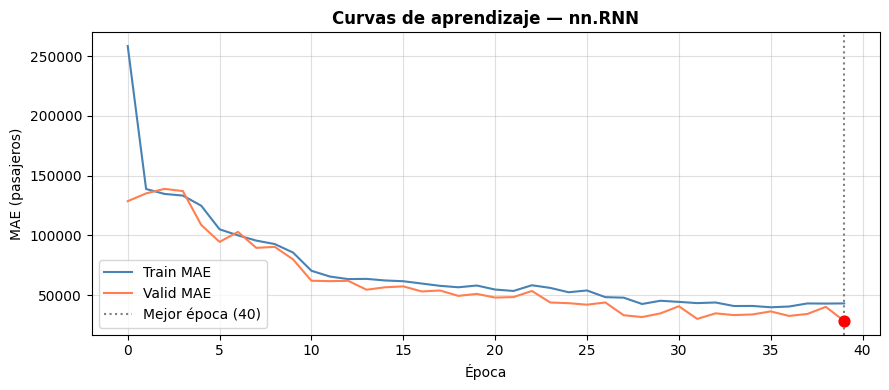

Mejor Valid MAE: 28,332 pasajeros (época 40)


In [ ]:
plot_learning_curves(history_rnn, "Curvas de aprendizaje — nn.RNN")


> 📌 **Salidas de `nn.RNN`**
>
> El módulo retorna dos objetos:
> - **`outputs`**: estados ocultos en **cada** paso de tiempo. Forma: `[batch, seq_len, hidden_size]`.
> - **`last_state`**: estado oculto **solo del último** paso de tiempo, para cada capa. Forma: `[num_layers, batch, hidden_size]`.
>
> Para pronóstico usamos `outputs[:, -1]`, equivalente a `last_state[0]` para redes de una capa.


---
### <font color="blue">**Actividad 4.** Comparación de implementaciones</font>

<font color="green">
Responde las siguientes preguntas con base en el código y los resultados de entrenamiento:

1. ¿Qué parámetro adicional tiene `nn.RNN` respecto a nuestra implementación manual? ¿Para qué sirve según el texto?
2. En el método `forward()` de `RnnModel`, ¿por qué usamos `outputs[:, -1]` y no `last_state[0]`? ¿Son equivalentes?
3. Ejecuta la celda siguiente y compara los tiempos de entrenamiento entre la RNN manual y `nn.RNN`. ¿A qué se debe la diferencia?
</font>


In [ ]:
criterion = nn.L1Loss()

for name, model in [("RNN manual", simple_model), ("nn.RNN", rnn_model)]:
    model_copy = model.to(device)
    model_copy.eval()
    t0 = time.time()
    with torch.no_grad():
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            _ = model_copy(X)
    elapsed = time.time() - t0
    print(f"{name:12s} → {elapsed:.4f} s por epoch (forward pass)")


RNN manual   → 0.1108 s por epoch (forward pass)
nn.RNN       → 0.0502 s por epoch (forward pass)


<details>
<summary>👉 Clic para ver respuesta orientativa</summary>

**1.** El parámetro adicional es `num_layers`, que permite apilar capas recurrentes. También internamente `nn.RNN` usa dos bias separados (`bias_ih` y `bias_hh`) por compatibilidad con cuDNN.

**2.** Son equivalentes para una red de una sola capa. `outputs[:, -1]` extrae el último paso temporal del tensor de salidas, mientras que `last_state[0]` extrae la capa 0 del estado final.

**3.** `nn.RNN` es más rápido porque su bucle está implementado en C++/CUDA. La RNN manual corre el bucle en Python, introduciendo mucho overhead.
</details>


---
## <font color="purple">7. Comparación de Modelos</font>

Evaluamos ambas implementaciones en el conjunto de prueba y visualizamos los pronósticos.


In [ ]:
criterion = nn.L1Loss()

test_mae_simple = evaluate(simple_model, test_loader, criterion, device)
test_mae_rnn    = evaluate(rnn_model,    test_loader, criterion, device)

print("=== MAE en conjunto de PRUEBA ===")
print(f"RNN manual : {test_mae_simple * 1e6:,.0f} pasajeros")
print(f"nn.RNN     : {test_mae_rnn * 1e6:,.0f} pasajeros")


=== MAE en conjunto de PRUEBA ===
RNN manual : 186,494 pasajeros
nn.RNN     : 97,109 pasajeros


In [ ]:
def get_predictions(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X, y in loader:
            X       = X.to(device)
            y_pred  = model(X).cpu().squeeze(-1)
            preds.append(y_pred)
            targets.append(y.squeeze(-1))
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()


preds_simple, targets_test = get_predictions(simple_model, test_loader, device)
preds_rnn,    _            = get_predictions(rnn_model,    test_loader, device)


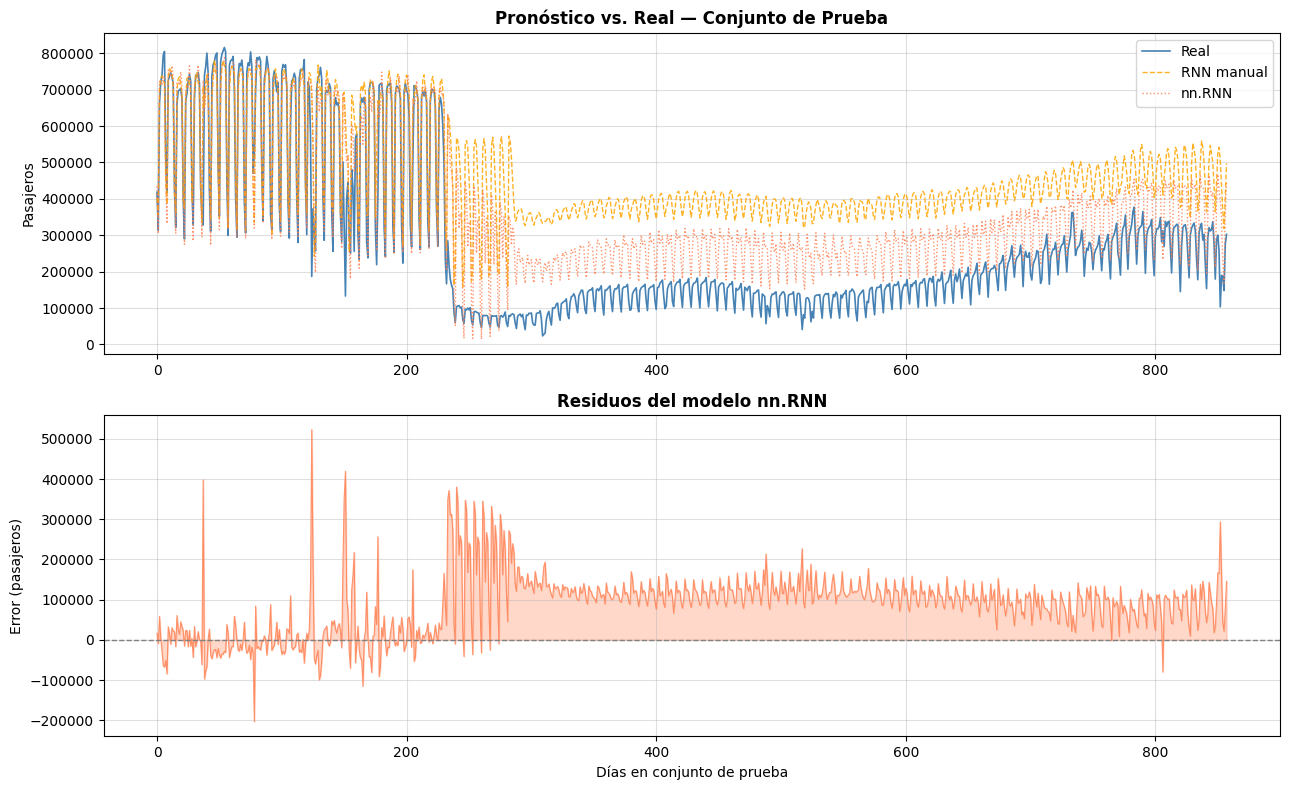

Media de residuos  : +87,548 pasajeros  (sesgo)
Std de residuos    : 77,912 pasajeros
Residuo máximo     : +522,953
Residuo mínimo     : -203,273


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# ── Panel superior: pronósticos vs real ──────────────────────────────────────
axes[0].plot(targets_test * 1e6,  label="Real",       color="steelblue",  linewidth=1.2)
axes[0].plot(preds_simple * 1e6,  label="RNN manual", color="orange",
             linestyle="--", linewidth=1.0, alpha=0.85)
axes[0].plot(preds_rnn * 1e6,     label="nn.RNN",     color="coral",
             linestyle=":",  linewidth=1.0, alpha=0.85)
axes[0].set_ylabel("Pasajeros")
axes[0].set_title("Pronóstico vs. Real — Conjunto de Prueba", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.4)

# ── Panel inferior: residuos del mejor modelo ─────────────────────────────────
residuals = (preds_rnn - targets_test) * 1e6
axes[1].plot(residuals, color="coral", linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color="grey",  linestyle="--", linewidth=1)
axes[1].fill_between(range(len(residuals)), residuals, alpha=0.3, color="coral")
axes[1].set_xlabel("Días en conjunto de prueba")
axes[1].set_ylabel("Error (pasajeros)")
axes[1].set_title("Residuos del modelo nn.RNN", fontweight="bold")
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

# Estadísticas de los residuos
print(f"Media de residuos  : {residuals.mean():+,.0f} pasajeros  (sesgo)")
print(f"Std de residuos    : {residuals.std():,.0f} pasajeros")
print(f"Residuo máximo     : {residuals.max():+,.0f}")
print(f"Residuo mínimo     : {residuals.min():+,.0f}")


---
### <font color="blue">**Actividad 6.** </font>

<font color="green">
Responde con tus propias palabras:

1. ¿Por qué se divide la serie temporal **respetando el tiempo** y no aleatoriamente? ¿Qué consecuencias tendría mezclar datos futuros en el entrenamiento (*data leakage*)?
2. En producción, el modelo recibirá **una sola secuencia** de 56 días para predecir el siguiente día. ¿Cómo adaptarías el código para usarlo en inferencia en tiempo real?
</font>


<details>
<summary>👉 Clic para ver puntos clave</summary>

**1. Data leakage**: Mezclar ventanas del futuro en el entrenamiento haría que el modelo "vea" patrones que no estarían disponibles en producción, generando una estimación del error optimistamente sesgada.

**2. Inferencia en tiempo real**:
```python
model.eval()
with torch.no_grad():
    last_56_days = rail_series[-56:].unsqueeze(0)  # [1, 56, 1]
    prediction   = model(last_56_days.to(device))
    print(f"Pronóstico mañana: {prediction.item() * 1e6:,.0f} pasajeros")
```
</details>


---
## Referencias

- Géron, A. (2025). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.). O'Reilly Media. Capítulo 13.
- PyTorch Documentation. `torch.nn.RNN`: https://pytorch.org/docs/stable/generated/torch.nn.RNN.html
- Chicago Transit Authority (CTA). *Ridership Dataset*: https://data.cityofchicago.org/
